### Imports

In [56]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import numpy as np
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

import sys
sys.path.insert(0, "..")

from model.data.load_data import LoadBaseSatelliteData
from vis_plotting.fp_plotting import *
from vis_plotting.general_plotting import *
from vis_plotting.topog_plotting import *


In [53]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Data loading

In [4]:
"""
Load the footprints for the region and period with the base data object.
Stores the footprints (without cropping) in data.fp_data_full
load_everything=True also loads the original meteorology, without cropping or interpolating, in data.met_file, as well as the topography and landuse in data.topog_file and data.landcover_file, which are interpolated in space to the shape of the footprints
"""
data = LoadBaseSatelliteData(201602, region="BRAZIL", load_everything=True, verbose=True)
#data = LoadBaseSatelliteData(201603, region="SAHARA", load_everything=True, verbose=True)
data.align_domains(crop_to_intersection=True)
data.get_country_masks()

---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_201602*.nc


no sampling was done because you didnt pass a valid sampling mode, or freq=1
Loading 1447 footprints

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/SOUTHAMERICA/SOUTHAMERICA_Met_201602*.nc

---- LOADING TOPOG
trying to load topography from /group/chem/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
---- All done!
Cropping to intersection:
  lat: -60.981 → 22.323
  lon: -91.329 → -24.801
trying to load country mask from /group/chem/acrg/LPDM/countries/country_SOUTHAMERICA.nc
country mask loaded successfully at self.countries.country_mask and landmask at self.countries.land_mask


## Jeff trying stuff out

In [5]:
countries = np.asarray(data.countries.country_mask["name"]).ravel()

In [6]:
countries

array(['OCEAN', 'VENEZUELA', 'URUGUAY', 'VIRGIN ISLANDS', 'PUERTO RICO',
       'SOUTH GEORGIA AND THE SOUTH SANDWICH ISLANDS',
       'FALKLAND ISLANDS (MALVINAS)', 'TRINIDAD AND TOBAGO', 'SURINAME',
       'SAINT LUCIA', 'PERU', 'PARAGUAY', 'PANAMA', 'NICARAGUA', 'MEXICO',
       'JAMAICA', 'HONDURAS', 'HAITI', 'GUYANA', 'GUATEMALA', 'GRENADA',
       'FRANCE', 'EL SALVADOR', 'ECUADOR', 'DOMINICAN REPUBLIC',
       'DOMINICA', 'CUBA', 'COSTA RICA', 'COLOMBIA', 'CHILE',
       'CABO VERDE', 'BRAZIL', 'BOLIVIA', 'BELIZE', 'BAHAMAS',
       'ARGENTINA', 'ANTIGUA AND BARBUDA'], dtype=object)

In [60]:
countries_to_plot = ["BRAZIL", "ARGENTINA", "CUBA"]
functions_to_run = [plot_topography_histogram, plot_landuse_frequency]



----- BRAZIL -----
Applying country mask for: BRAZIL
trying to load country mask from /group/chem/acrg/LPDM/countries/country_SOUTHAMERICA.nc
country mask loaded successfully at self.countries.country_mask and landmask at self.countries.land_mask


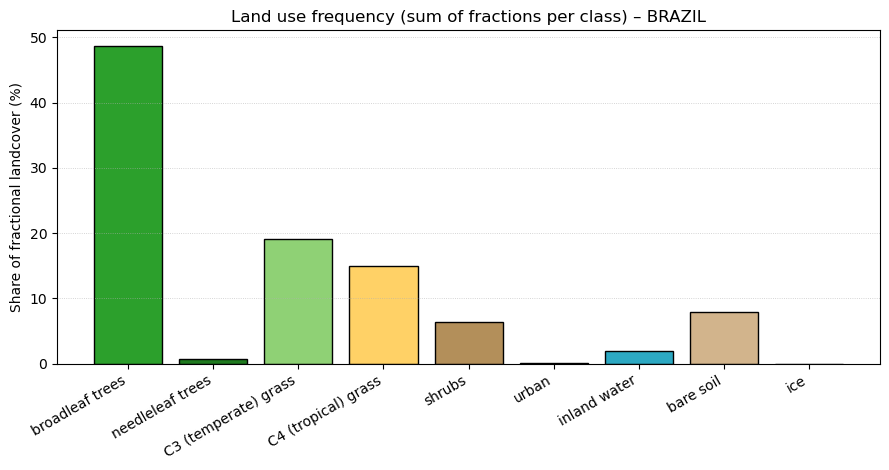


----- ARGENTINA -----
Applying country mask for: ARGENTINA
trying to load country mask from /group/chem/acrg/LPDM/countries/country_SOUTHAMERICA.nc
country mask loaded successfully at self.countries.country_mask and landmask at self.countries.land_mask


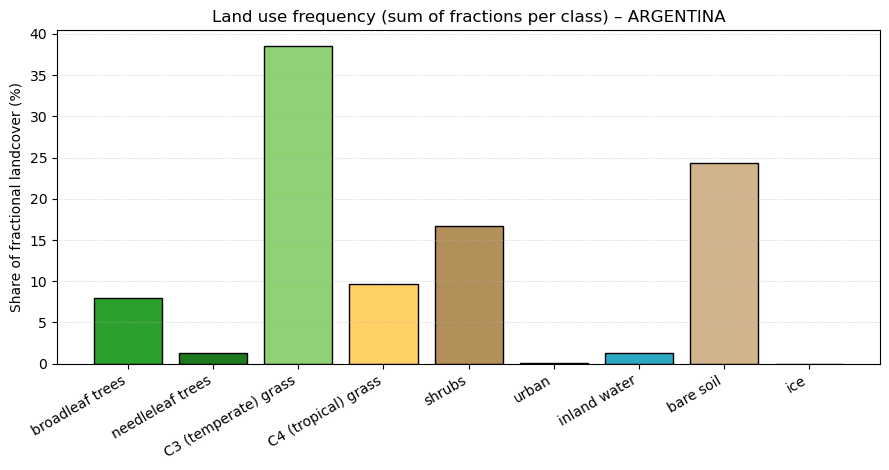


----- CUBA -----
Applying country mask for: CUBA
trying to load country mask from /group/chem/acrg/LPDM/countries/country_SOUTHAMERICA.nc
country mask loaded successfully at self.countries.country_mask and landmask at self.countries.land_mask


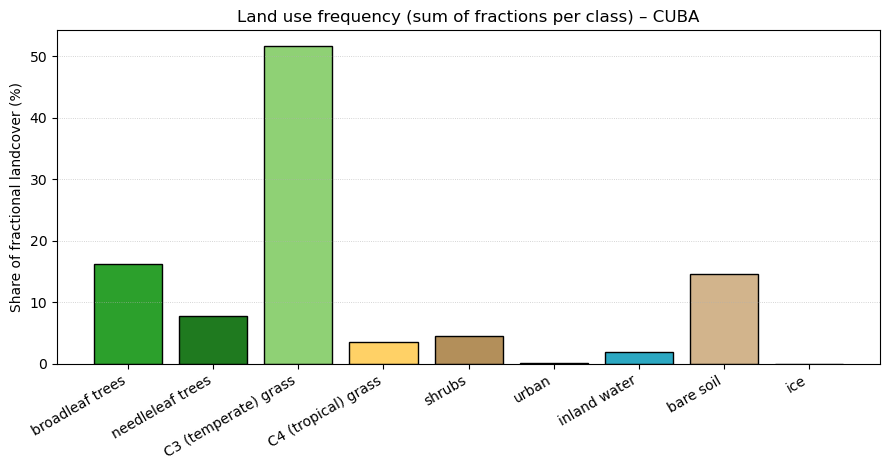

In [61]:
loop_over_countries(data, plot_landuse_frequency, countries_to_plot)

--- plot_topography_histogram ---

----- Global (no country mask) -----


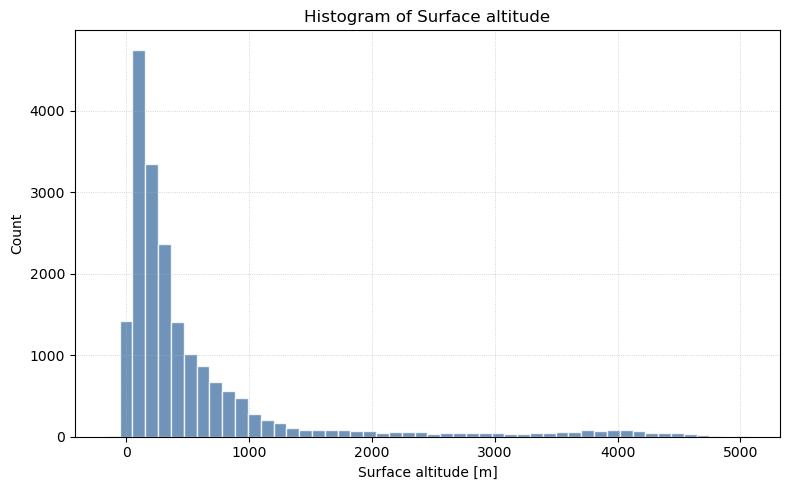

--- plot_landuse_frequency ---

----- Global (no country mask) -----


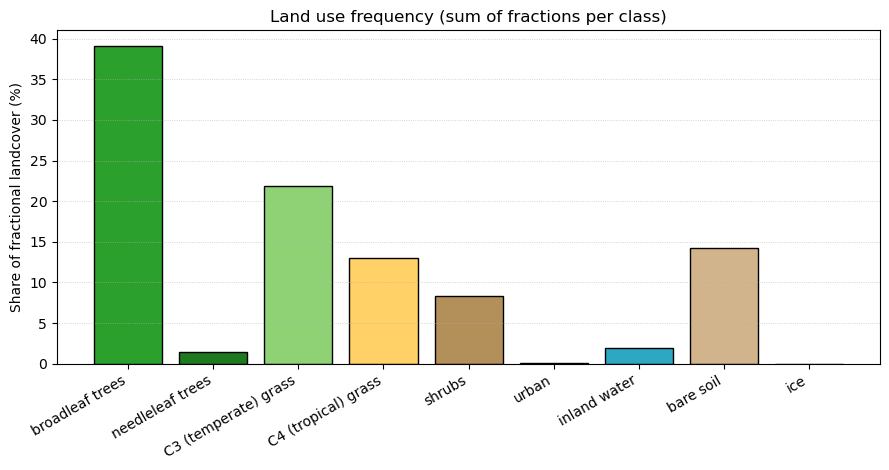

In [62]:
run_all_plots(
    data,
    plot_functions=functions_to_run,
    countries=None,
    #log_y=True,
)

--- plot_topography_histogram ---

----- BRAZIL -----
Applying country mask for: BRAZIL
trying to load country mask from /group/chem/acrg/LPDM/countries/country_SOUTHAMERICA.nc
country mask loaded successfully at self.countries.country_mask and landmask at self.countries.land_mask


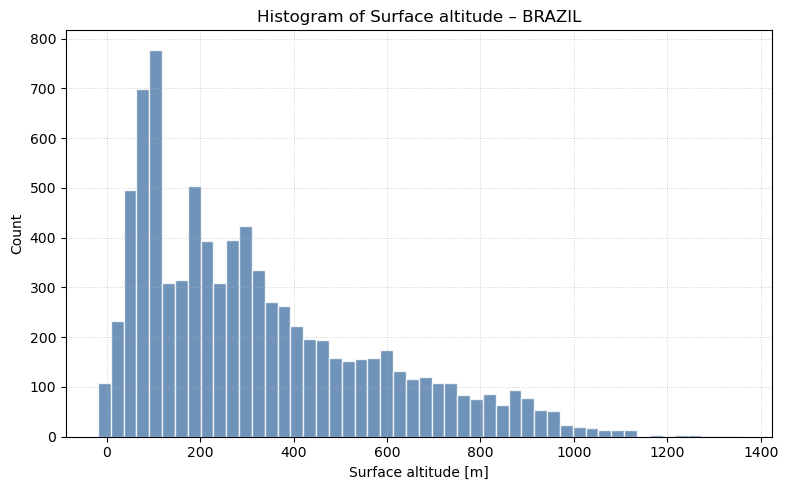


----- ARGENTINA -----
Applying country mask for: ARGENTINA
trying to load country mask from /group/chem/acrg/LPDM/countries/country_SOUTHAMERICA.nc
country mask loaded successfully at self.countries.country_mask and landmask at self.countries.land_mask


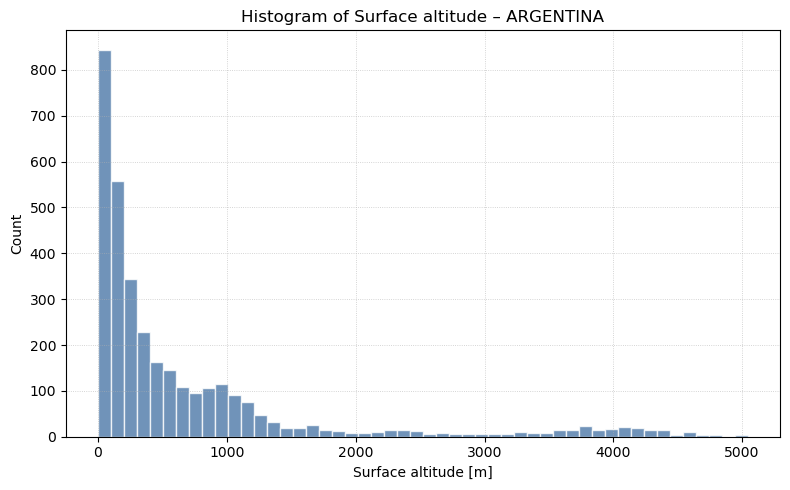


----- CUBA -----
Applying country mask for: CUBA
trying to load country mask from /group/chem/acrg/LPDM/countries/country_SOUTHAMERICA.nc
country mask loaded successfully at self.countries.country_mask and landmask at self.countries.land_mask


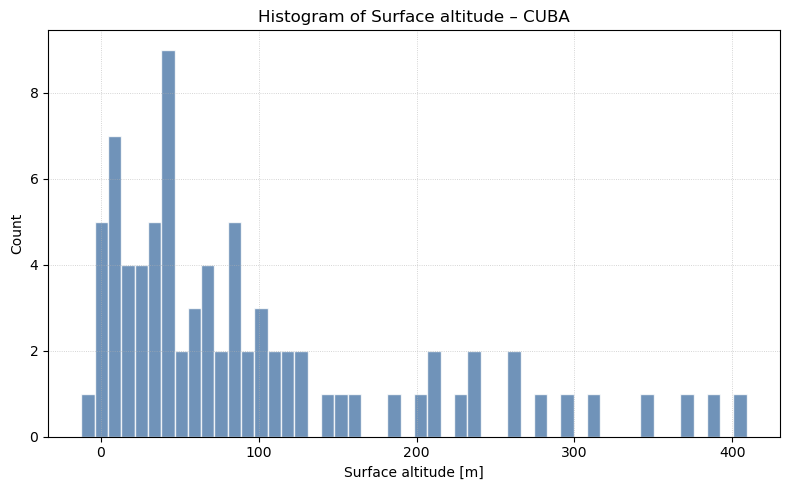

--- plot_landuse_frequency ---

----- BRAZIL -----
Applying country mask for: BRAZIL
trying to load country mask from /group/chem/acrg/LPDM/countries/country_SOUTHAMERICA.nc
country mask loaded successfully at self.countries.country_mask and landmask at self.countries.land_mask


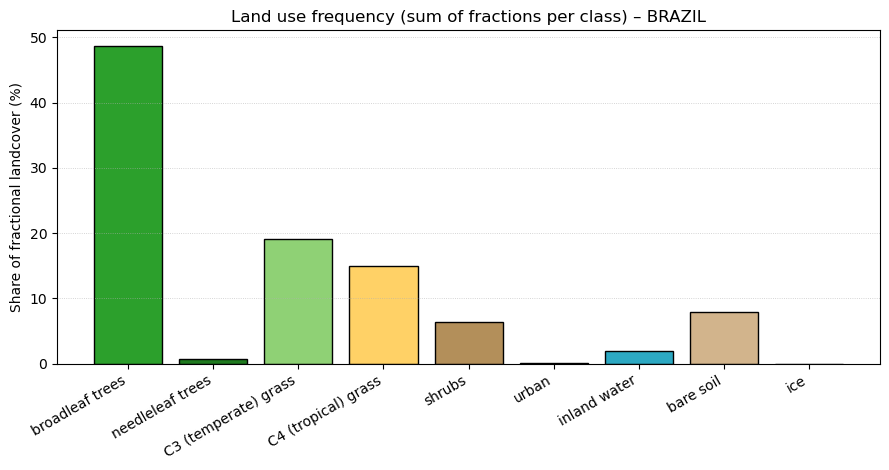


----- ARGENTINA -----
Applying country mask for: ARGENTINA
trying to load country mask from /group/chem/acrg/LPDM/countries/country_SOUTHAMERICA.nc
country mask loaded successfully at self.countries.country_mask and landmask at self.countries.land_mask


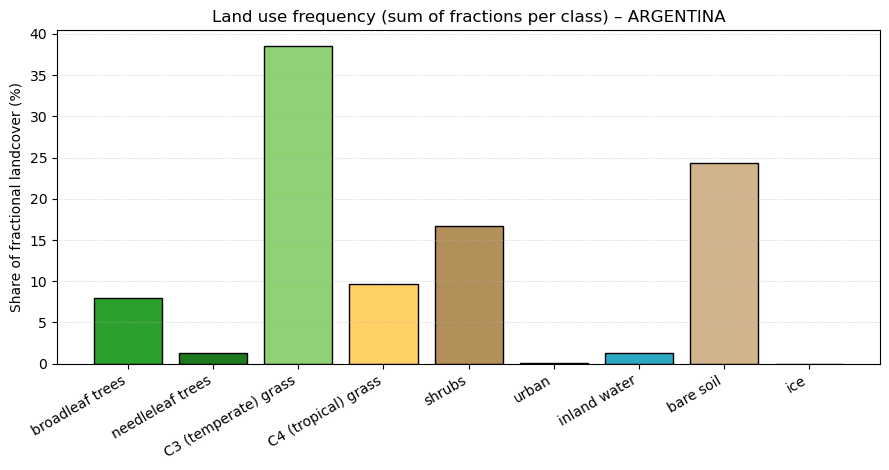


----- CUBA -----
Applying country mask for: CUBA
trying to load country mask from /group/chem/acrg/LPDM/countries/country_SOUTHAMERICA.nc
country mask loaded successfully at self.countries.country_mask and landmask at self.countries.land_mask


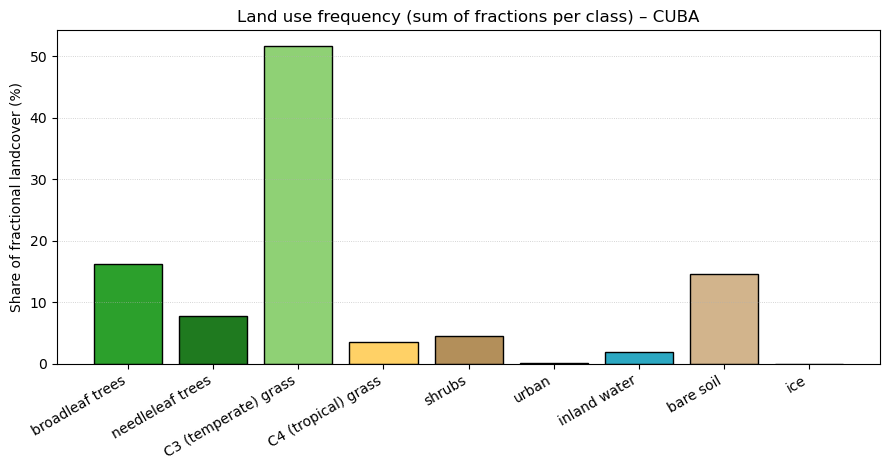

In [63]:
run_all_plots(
    data,
    plot_functions=functions_to_run,
    countries=countries_to_plot,
    #log_y=True,
)

### Plot map with bounding box for data

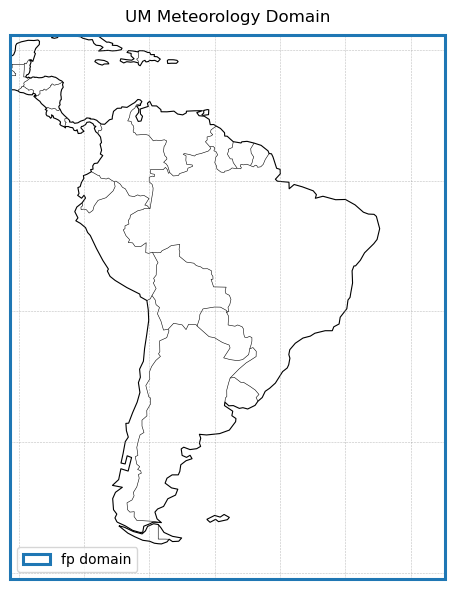

In [ ]:
# Can also constrain to only showing the fp domain
fig, ax = plot_domain(
    data,
    type = "fp",
    projection="PlateCarree",  # "PlateCarree" gives a true lon/lat view; "Robinson" for global context
    zoom_to_data=True,
    title="UM Meteorology Domain"
)
plt.show()
# {'min_lat': -60.98099899291992, 'max_lat': 22.322999954223633, 'min_lon': -91.3290023803711, 'max_lon': -24.801000595092773}

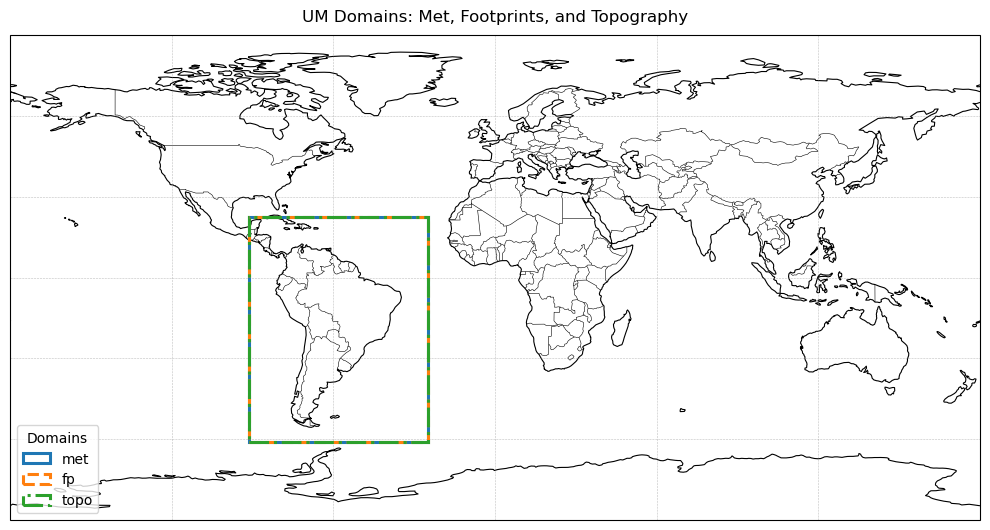

In [ ]:
# Plot all three with distinct styles, zooming to the union of their extents
fig, ax = plot_multiple_data_series(
    data,
    show=("met", "fp", "topo"),
    colours={"met":"tab:blue", "fp":"tab:orange", "topo":"tab:green"},
    linestyles={"met":"-", "fp":"--", "topo":"-."},
    linewidths={"met":2.2, "fp":2.2, "topo":2.2},
    facealpha=0.0,                 # set to, e.g., 0.15 if you want light fills
    projection="PlateCarree",
    wrap_center=0,
    zoom_to_union=False,
    title="UM Domains: Met, Footprints, and Topography"
)
plt.show()

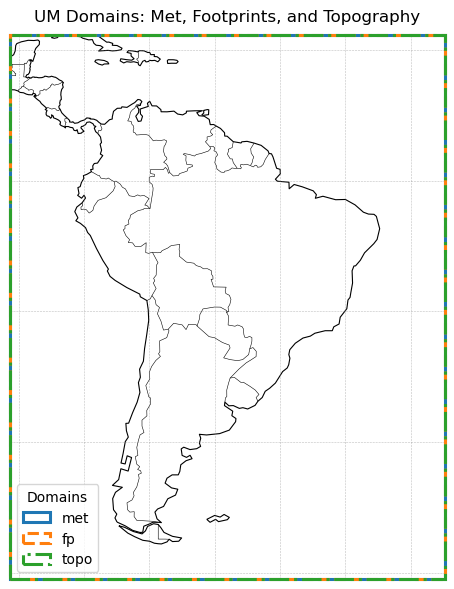

In [ ]:
# Plot all three with distinct styles, zooming to the union of their extents
fig, ax = plot_multiple_data_series(
    data,
    show=("met", "fp", "topo"),
    colours={"met":"tab:blue", "fp":"tab:orange", "topo":"tab:green"},
    linestyles={"met":"-", "fp":"--", "topo":"-."},
    linewidths={"met":2.2, "fp":2.2, "topo":2.2},
    facealpha=0.0,                 # set to, e.g., 0.15 if you want light fills
    projection="PlateCarree",
    wrap_center=0,
    zoom_to_union=True,
    title="UM Domains: Met, Footprints, and Topography"
)
plt.show()

### Plot topo

Applying country mask for: BRAZIL
trying to load country mask from /group/chem/acrg/LPDM/countries/country_SOUTHAMERICA.nc
country mask loaded successfully at self.countries.country_mask and landmask at self.countries.land_mask


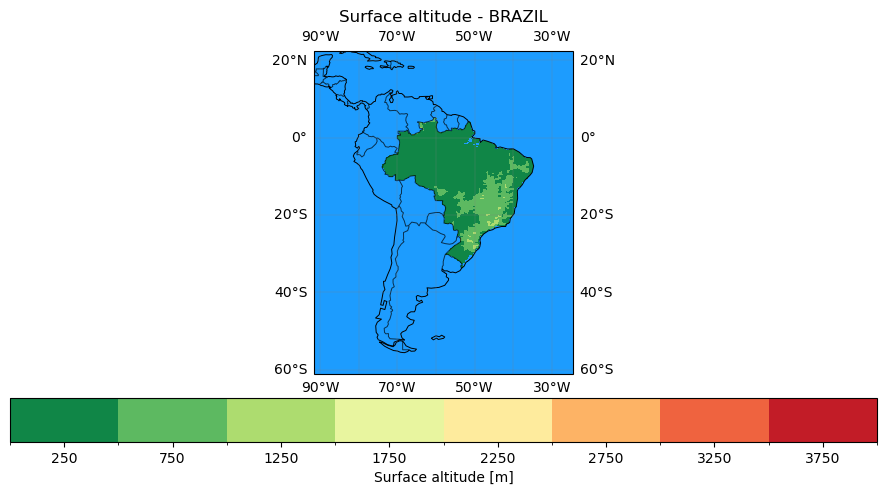

In [ ]:
fig, ax, mesh, edges = plot_topography(
    data,
    n_bins=8,
    country = "BRAZIL",
    vmin=0, vmax=4000, # Max altitude in metres
    plot_country_boundaries=True
)

### Histogram of topography

Applying country mask for: BRAZIL
trying to load country mask from /group/chem/acrg/LPDM/countries/country_SOUTHAMERICA.nc
country mask loaded successfully at self.countries.country_mask and landmask at self.countries.land_mask


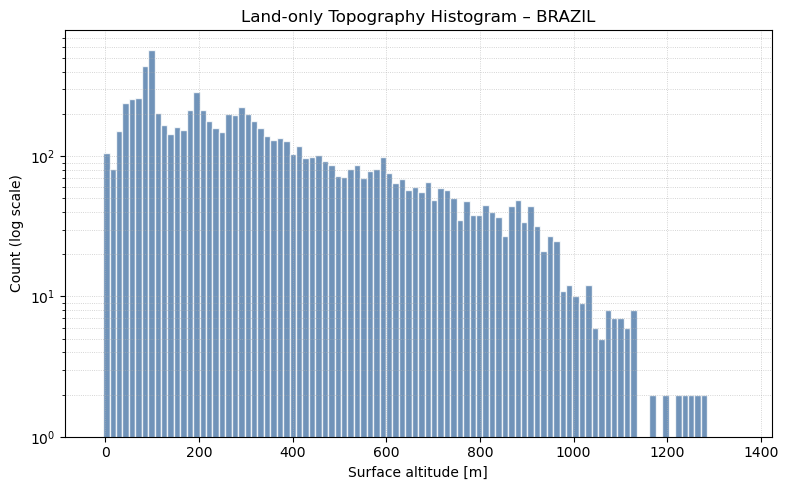

In [ ]:
fig, ax, _ = plot_topography_histogram(
    data,
    bins=100, #Or can be eg np.arange(-500, 6000, 100)
    country = 'BRAZIL',
    log_y=True,
    density=False,
    title="Land-only Topography Histogram"
)

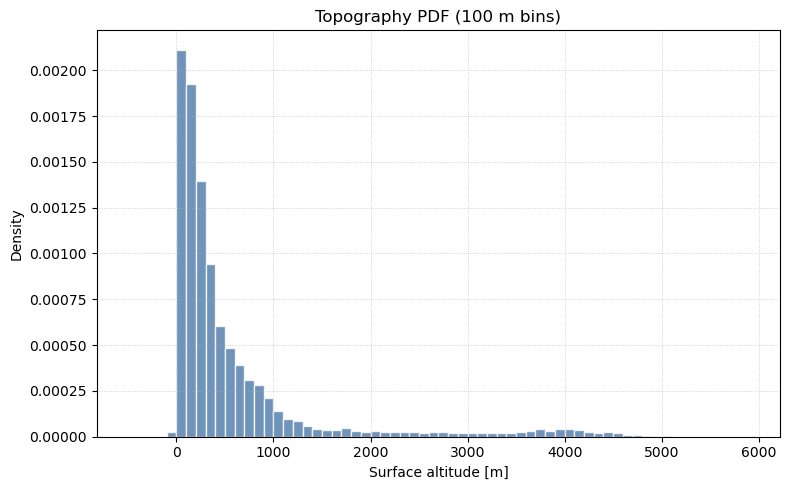

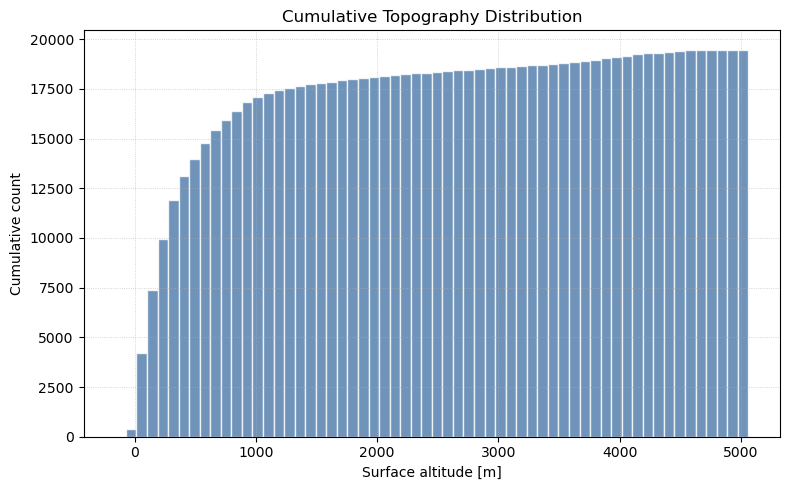

In [ ]:
# Two more examples: 
# Probability density function
fig, ax, _ = plot_topography_histogram(
    data,
    bins=np.arange(-500, 6000, 100),
    density=True,
    title="Topography PDF (100 m bins)"
)

# Cumulative distribution function
fig, ax, _ = plot_topography_histogram(
    data,
    bins=60,
    cumulative=True,
    title="Cumulative Topography Distribution"
)

### Land-use

Applying country mask for: ARGENTINA
trying to load country mask from /group/chem/acrg/LPDM/countries/country_SOUTHAMERICA.nc
country mask loaded successfully at self.countries.country_mask and landmask at self.countries.land_mask


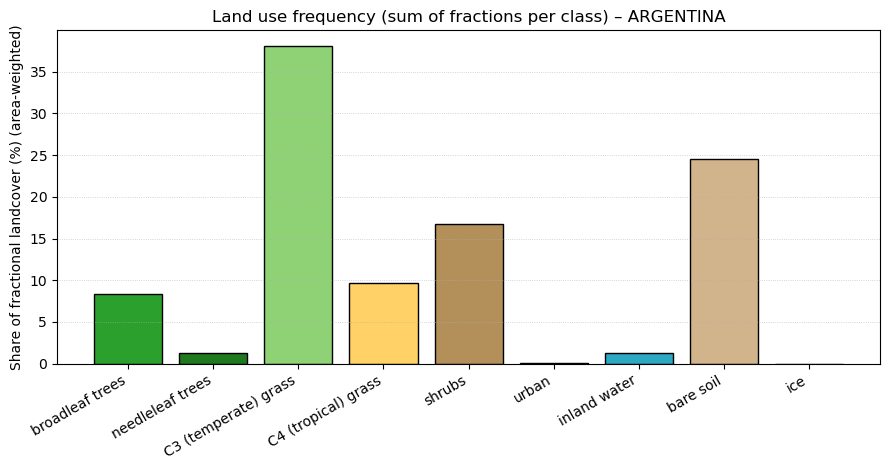

In [ ]:
fig, ax, freq = plot_landuse_frequency(data,
                                       country = "ARGENTINA",
                                        area_weighted=True,
                                       )

Applying country mask for: PERU
trying to load country mask from /group/chem/acrg/LPDM/countries/country_SOUTHAMERICA.nc
country mask loaded successfully at self.countries.country_mask and landmask at self.countries.land_mask


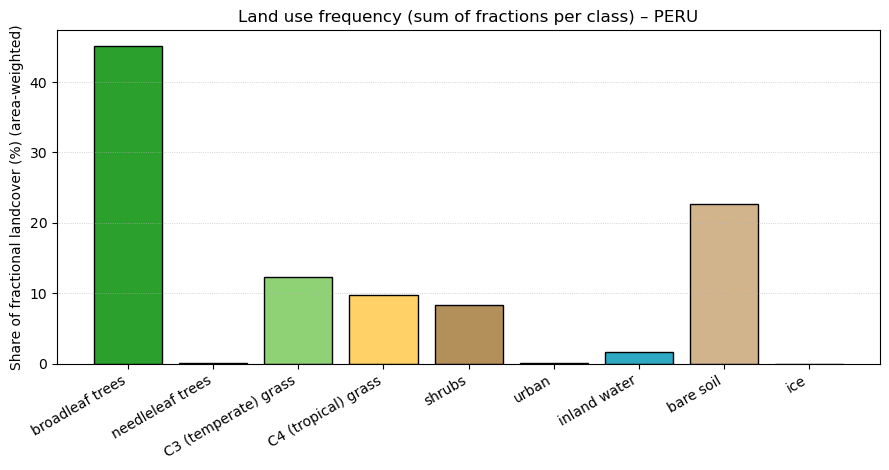

In [ ]:
fig, ax, freq = plot_landuse_frequency(data,
                                       country = "PERU",
                                        area_weighted=True,
                                       )

Applying country mask for: ARGENTINA
trying to load country mask from /group/chem/acrg/LPDM/countries/country_SOUTHAMERICA.nc
country mask loaded successfully at self.countries.country_mask and landmask at self.countries.land_mask


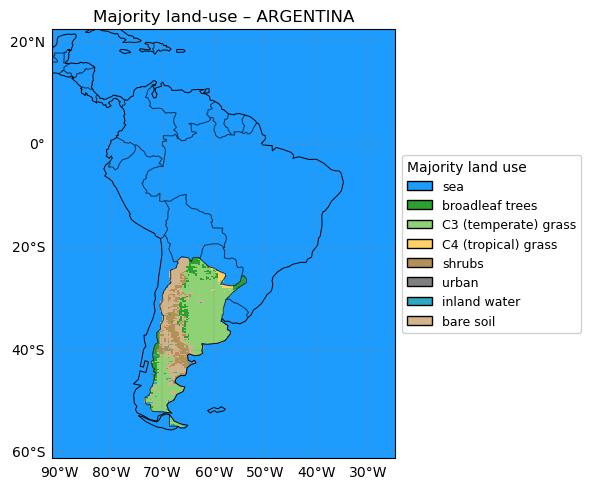

In [ ]:
fig, ax, mesh, majority, (cmap, norm) = plot_majority_landuse_map(
    data,
    #country = "ARGENTINA",
    title="Majority land‑use"
)

In [ ]:
# To do
# Move default colours stuff from topog_plotting to yaml/config?

# Compare regions

In [ ]:
def compare_topography_maps(
    data_A, data_B,
    region_names=("Region A", "Region B"),
    n_bins=10, vmin=None, vmax=None,
    cmap='RdYlGn_r',
    ocean_colour="#1d9cfe",
    land_only=True,
    figure_size=(13, 5.5),
    plot_country_boundaries=True,
):
    # Compute common bin edges from land-only samples
    zA = get_topography_values(data_A, land_only=land_only)
    zB = get_topography_values(data_B, land_only=land_only)
    bin_edges = common_bin_edges(zA, zB, n_bins=n_bins, vmin=vmin, vmax=vmax)
    lo, hi = bin_edges[0], bin_edges[-1]
    centres = 0.5*(bin_edges[:-1] + bin_edges[1:])
    base_cmap = plt.get_cmap(cmap)
    centres01 = (centres - lo) / (hi - lo + 1e-15)
    colours = base_cmap(centres01)
    discrete_cmap = ListedColormap(colours, name=f"{cmap}_{n_bins}bins")
    discrete_cmap.set_bad(ocean_colour)
    norm = BoundaryNorm(bin_edges, ncolors=discrete_cmap.N, clip=True)

    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=figure_size, constrained_layout=True)
    axs = [plt.subplot(1, 2, i+1, projection=proj) for i in range(2)]

    for ax, data, title in zip(axs, [data_A, data_B], region_names):
        ds = data.topog_file
        da = ds['surface_altitude'].where(np.isfinite(ds['surface_altitude']))
        if land_only:
            lm = get_land_mask(data)
            if lm is not None:
                da = da.where(lm)
        lon = ds['lon'].values
        lat = ds['lat'].values

        ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
        if plot_country_boundaries:
            ax.add_feature(cfeature.BORDERS, linewidth=0.7, edgecolor="black", alpha=0.7)
        ax.gridlines(draw_labels=False, linewidth=0.3, color='0.5', alpha=0.6)

        mesh = ax.pcolormesh(
            lon, lat, da.values,
            transform=proj, cmap=discrete_cmap, norm=norm, shading='auto'
        )
        ax.set_title(title)

    # One shared colourbar
    cb = fig.colorbar(
        mesh, ax=axs, orientation='horizontal', pad=0.05, shrink=0.9,
        boundaries=bin_edges, ticks=centres
    )
    units = data_A.topog_file['surface_altitude'].attrs.get('units', 'm')
    long_name = data_A.topog_file['surface_altitude'].attrs.get('long_name', 'Surface altitude')
    cb.set_label(f"{long_name} [{units}]")
    try:
        cb.ax.set_xticklabels([f"{v:.0f}" for v in centres])
    except Exception:
        pass

    plt.show()
    return fig, axs, (discrete_cmap, norm, bin_edges)

In [ ]:
def get_land_mask(data, threshold=0.9):
    """Return a boolean mask (lat, lon) with True for land cells."""
    if hasattr(data, 'landcover_file') and 'land_binary_mask' in data.landcover_file.variables:
        return (data.landcover_file['land_binary_mask'] > threshold)
    # Fallback: anything non-NaN in landcover_fraction implies land; else ~all NaN is ocean.
    if hasattr(data, 'landcover_file') and 'landcover_fraction' in data.landcover_file.variables:
        da = data.landcover_file['landcover_fraction']
        # normalise dims to (lat, lon, pseudo_level)
        if da.dims == ('pseudo_level', 'lat', 'lon'):
            da = da.transpose('lat', 'lon', 'pseudo_level')
        return np.isfinite(da).any(dim='pseudo_level')
    # If we cannot infer, return None
    return None

def get_topography_values(data, land_only=True, land_threshold=0.9):
    """Flattened surface altitude vector (optionally land-only)."""
    da = data.topog_file['surface_altitude'].where(np.isfinite(data.topog_file['surface_altitude']))
    if land_only:
        lm = get_land_mask(data, threshold=land_threshold)
        if lm is not None:
            da = da.where(lm)
    z = da.values.ravel()
    return z[np.isfinite(z)]

def common_bin_edges(zA, zB, n_bins=25, vmin=None, vmax=None):
    """Compute common equally spaced bin edges for zA and zB."""
    lo = np.nanmin([zA.min() if zA.size else np.nan, zB.min() if zB.size else np.nan]) if vmin is None else float(vmin)
    hi = np.nanmax([zA.max() if zA.size else np.nan, zB.max() if zB.size else np.nan]) if vmax is None else float(vmax)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
        raise ValueError("Invalid vmin/vmax or empty arrays for common binning.")
    return np.linspace(lo, hi, n_bins + 1)

Cropping to intersection:
  lat: -7.980 → 40.926
  lon: -44.016 → 68.272
Cropping to intersection:
  lat: -60.981 → 22.323
  lon: -91.329 → -24.801


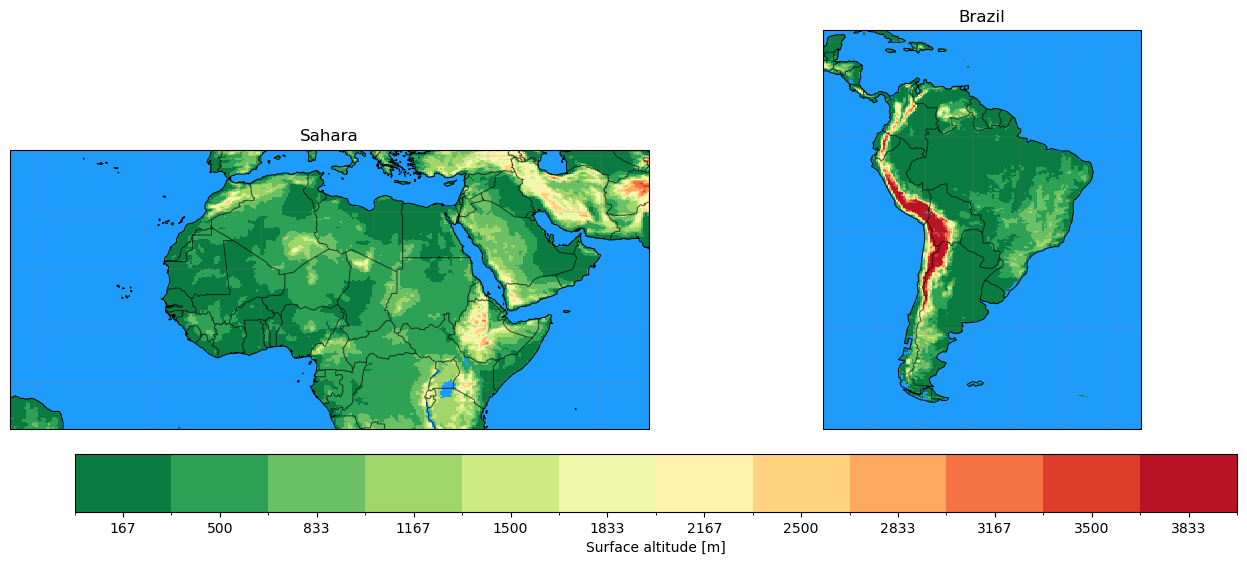

(<Figure size 1300x550 with 3 Axes>,
 [<GeoAxes: title={'center': 'Sahara'}>,
  <GeoAxes: title={'center': 'Brazil'}>],
 (<matplotlib.colors.ListedColormap at 0x7f7f7c410b00>,
  array([   0.        ,  333.33333333,  666.66666667, 1000.        ,
         1333.33333333, 1666.66666667, 2000.        , 2333.33333333,
         2666.66666667, 3000.        , 3333.33333333, 3666.66666667,
         4000.        ])))

In [ ]:
data_A = LoadBaseSatelliteData(201603, region="SAHARA", load_everything=True, verbose=False)
data_B = LoadBaseSatelliteData(201603, region="BRAZIL", load_everything=True, verbose=False)

data_A.align_domains(crop_to_intersection=True)
data_B.align_domains(crop_to_intersection=True)

compare_topography_maps(
    data_A, data_B,
    region_names=("Sahara", "Brazil"),
    n_bins=12, vmin=0, vmax=4000, cmap='RdYlGn_r', land_only=True
)

In [ ]:
def compare_topography_histograms(
    data_A, data_B,
    region_names=("Region A", "Region B"),
    n_bins=30, vmin=None, vmax=None,
    land_only=True,
    density=False, cumulative=False, log_y=False,
    colours=("#1f77b4", "#d62728"),
    figsize=(8, 5),
):
    zA = get_topography_values(data_A, land_only=land_only)
    zB = get_topography_values(data_B, land_only=land_only)
    bin_edges = common_bin_edges(zA, zB, n_bins=n_bins, vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=figsize)
    ax.hist(zA, bins=bin_edges, density=density, cumulative=cumulative,
            histtype='step', linewidth=1.8, color=colours[0], label=region_names[0])
    ax.hist(zB, bins=bin_edges, density=density, cumulative=cumulative,
            histtype='step', linewidth=1.8, color=colours[1], label=region_names[1])

    y_label = 'Density' if density else ('Cumulative count' if cumulative else 'Count')
    if log_y:
        ax.set_yscale('log'); y_label += ' (log scale)'

    units = data_A.topog_file['surface_altitude'].attrs.get('units', 'm')
    long_name = data_A.topog_file['surface_altitude'].attrs.get('long_name', 'Surface altitude')
    ax.set_xlabel(f"{long_name} [{units}]")
    ax.set_ylabel(y_label)
    ax.grid(True, which='both', linestyle=':', linewidth=0.6, alpha=0.7)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return fig, ax, bin_edges

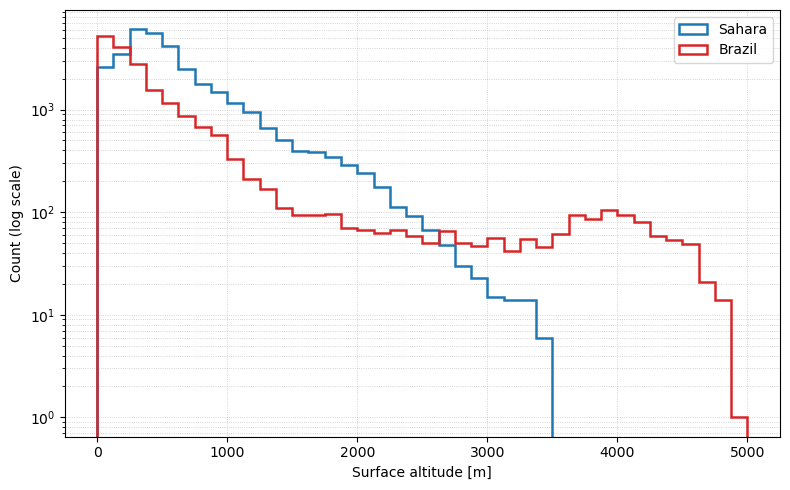

(<Figure size 800x500 with 1 Axes>,
 <Axes: xlabel='Surface altitude [m]', ylabel='Count (log scale)'>,
 array([   0.,  125.,  250.,  375.,  500.,  625.,  750.,  875., 1000.,
        1125., 1250., 1375., 1500., 1625., 1750., 1875., 2000., 2125.,
        2250., 2375., 2500., 2625., 2750., 2875., 3000., 3125., 3250.,
        3375., 3500., 3625., 3750., 3875., 4000., 4125., 4250., 4375.,
        4500., 4625., 4750., 4875., 5000.]))

In [ ]:
compare_topography_histograms(
    data_A, data_B,
    region_names=("Sahara", "Brazil"),
    n_bins=40, vmin=0, vmax=5000, land_only=True, log_y=True, density=False
)

In [ ]:
from matplotlib.gridspec import GridSpec

def majority_landuse_da(data):
    da = data.landcover_file['landcover_fraction']
    if da.dims == ('pseudo_level', 'lat', 'lon'):
        da = da.transpose('lat', 'lon', 'pseudo_level')
    valid = np.isfinite(da).any(dim='pseudo_level')
    filled = da.fillna(-1e15)
    idx = filled.argmax(dim='pseudo_level')
    pseudo_ids = da['pseudo_level']
    maj = pseudo_ids.isel(pseudo_level=idx).astype(int)
    maj = xr.where(valid, maj, 0).astype(int)
    return maj

def compare_majority_landuse_maps(
    data_A, data_B,
    region_names=("Region A", "Region B"),
    figure_size=(13, 5.5),
    plot_country_boundaries=True,
    coastline=True,
):
    majA = majority_landuse_da(data_A)
    majB = majority_landuse_da(data_B)
    lonA, latA = majA['lon'].values, majA['lat'].values
    lonB, latB = majB['lon'].values, majB['lat'].values

    ordered_ids = list(range(0, 10))
    colours_list = [CLASS_COLOURS[i] for i in ordered_ids]
    cmap = ListedColormap(colours_list, name="landuse_maj_0to9")
    boundaries = np.arange(-0.5, 10.5, 1.0)
    norm = BoundaryNorm(boundaries, ncolors=cmap.N, clip=False)

    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=figure_size, constrained_layout=True)
    gs = GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 0.22])
    ax1 = fig.add_subplot(gs[0, 0], projection=proj)
    ax2 = fig.add_subplot(gs[0, 1], projection=proj)
    ax_leg = fig.add_subplot(gs[0, 2])  # legend area (no map)

    for ax, maj, lon, lat, title in [
        (ax1, majA, lonA, latA, region_names[0]),
        (ax2, majB, lonB, latB, region_names[1]),
    ]:
        if coastline:
            ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
        if plot_country_boundaries:
            ax.add_feature(cfeature.BORDERS, linewidth=0.7, edgecolor="black", alpha=0.7)
        ax.gridlines(draw_labels=False, linewidth=0.3, color='0.5', alpha=0.6)
        ax.pcolormesh(lon, lat, maj.values, transform=proj, cmap=cmap, norm=norm, shading='nearest')
        ax.set_title(title)

    # Build a categorical legend showing *only* classes that appear in either panel
    present_ids = np.unique(np.concatenate([
        np.unique(majA.values[np.isfinite(majA.values)]),
        np.unique(majB.values[np.isfinite(majB.values)])
    ])).astype(int)
    present_ids = [i for i in present_ids if 0 <= i <= 9]
    handles = [Patch(facecolor=CLASS_COLOURS[i], edgecolor='black', label=CLASS_LABELS[i])
               for i in present_ids]

    ax_leg.axis('off')
    leg = ax_leg.legend(
        handles=handles, loc='center', frameon=True, framealpha=0.95,
        title="Majority land‑use", fontsize=9
    )
    try:
        leg._legend_box.align = "left"
    except Exception:
        pass

    plt.show()
    return fig, (ax1, ax2), (majA, majB), (cmap, norm)

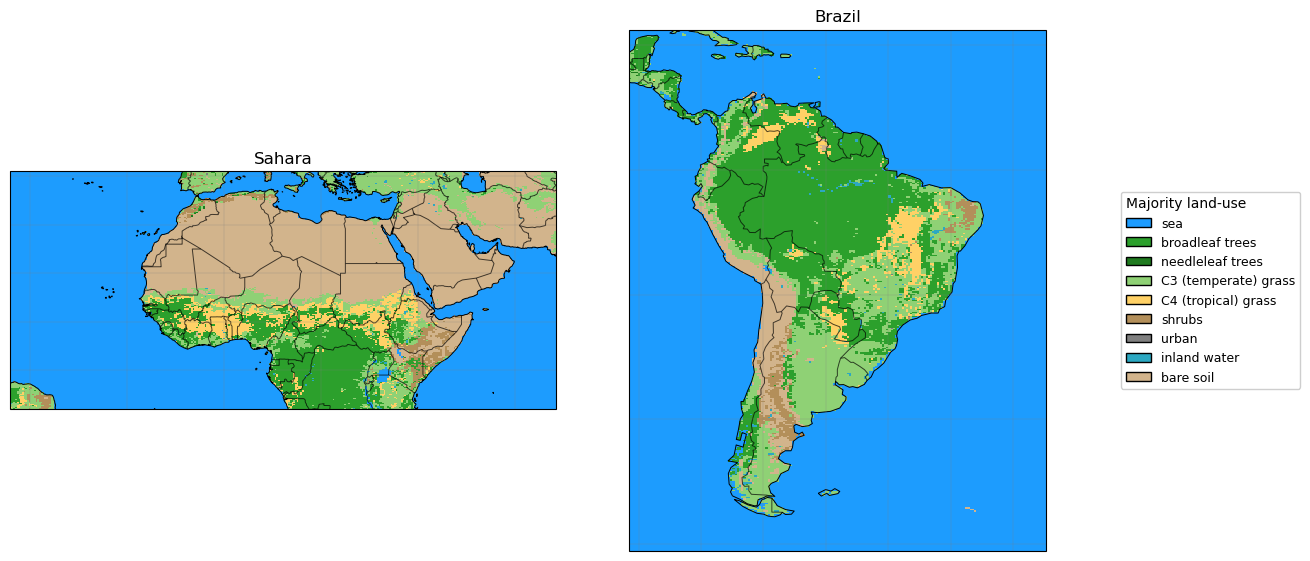

(<Figure size 1300x550 with 3 Axes>,
 (<GeoAxes: title={'center': 'Sahara'}>,
  <GeoAxes: title={'center': 'Brazil'}>),
 (<xarray.DataArray (lat: 210, lon: 320)>
  array([[3, 3, 1, ..., 0, 0, 0],
         [4, 3, 3, ..., 0, 0, 0],
         [3, 3, 3, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 3, 3, 3],
         [0, 0, 0, ..., 8, 3, 3],
         [0, 0, 0, ..., 3, 3, 3]])
  Coordinates:
    * lat           (lat) float32 -7.98 -7.746 -7.512 -7.278 ... 40.46 40.69 40.93
    * lon           (lon) float32 -44.02 -43.66 -43.31 ... 67.57 67.92 68.27
      pseudo_level  (lat, lon) int32 3 3 1 3 3 3 3 3 3 3 3 ... 8 3 3 3 3 3 8 3 3 3,
  <xarray.DataArray (lat: 357, lon: 190)>
  array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]])
  Coordinates:
    * lat           (lat) float32 -60.98 -60.75 -60.51 ... 21.85 22.09 22.32
    * l

In [ ]:
compare_majority_landuse_maps(
    data_A, data_B,
    region_names=("Sahara", "Brazil"),
    plot_country_boundaries=True
)

In [ ]:
def landuse_totals(data, area_weighted=False, as_percent=True):
    da = data.landcover_file['landcover_fraction']
    if da.dims == ('pseudo_level', 'lat', 'lon'):
        da = da.transpose('lat', 'lon', 'pseudo_level')
    if area_weighted:
        lat = da['lat'].values
        cosw = np.cos(np.deg2rad(lat))
        weights2d = xr.DataArray(
            np.repeat(cosw[:, None], da.sizes['lon'], axis=1),
            coords={'lat': da['lat'], 'lon': da['lon']},
            dims=('lat', 'lon')
        )
        daw = da * weights2d.broadcast_like(da)
        summed = daw.sum(dim=('lat', 'lon'), skipna=True)
    else:
        summed = da.sum(dim=('lat', 'lon'), skipna=True)
    class_ids = [int(c) for c in da['pseudo_level'].values.tolist()]
    totals = np.array(summed.values, dtype=float)
    freq = {cid: totals[i] for i, cid in enumerate(class_ids) if np.isfinite(totals[i])}
    if as_percent:
        s = np.sum(list(freq.values()))
        if s > 0:
            freq = {k: v/s*100.0 for k, v in freq.items()}
    return freq

def compare_landuse_frequency(
    data_A, data_B,
    region_names=("Region A", "Region B"),
    area_weighted=True, as_percent=True,
    figsize=(10, 4.8),
    hatch_A="", hatch_B="//"
):
    freqA = landuse_totals(data_A, area_weighted=area_weighted, as_percent=as_percent)
    freqB = landuse_totals(data_B, area_weighted=area_weighted, as_percent=as_percent)

    # Union of classes present (sorted)
    plot_ids = sorted(set(freqA.keys()).union(freqB.keys()))
    labels = [CLASS_LABELS.get(cid, f"class {cid}") for cid in plot_ids]
    valsA = [freqA.get(cid, 0.0) for cid in plot_ids]
    valsB = [freqB.get(cid, 0.0) for cid in plot_ids]
    colours = [CLASS_COLOURS.get(cid, "steelblue") for cid in plot_ids]

    x = np.arange(len(plot_ids))
    width = 0.38

    fig, ax = plt.subplots(figsize=figsize)
    barsA = ax.bar(x - width/2, valsA, width=width, color=colours, edgecolor='black', hatch=hatch_A, label=region_names[0])
    barsB = ax.bar(x + width/2, valsB, width=width, color=colours, edgecolor='black', hatch=hatch_B, label=region_names[1])

    y_label = "Share of fractional landcover (%)" if as_percent else "Total fractional landcover"
    if area_weighted:
        y_label += " (area-weighted)"
    ax.set_ylabel(y_label)
    ax.set_title("Land‑use frequency by class")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.grid(True, axis='y', linestyle=':', linewidth=0.6, alpha=0.7)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return fig, ax, (freqA, freqB)

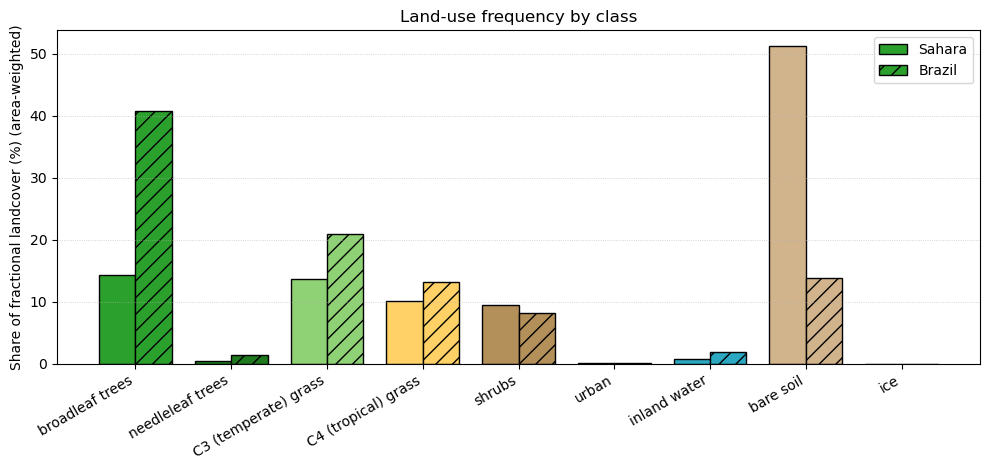

(<Figure size 1000x480 with 1 Axes>,
 <Axes: title={'center': 'Land‑use frequency by class'}, ylabel='Share of fractional landcover (%) (area-weighted)'>,
 ({1: 14.363404285643162,
   2: 0.4093976232954397,
   3: 13.617966896379318,
   4: 10.120641612428864,
   5: 9.533141729671454,
   6: 0.039562090270537316,
   7: 0.7122665612826506,
   8: 51.20361920102857,
   9: 0.0},
  {1: 40.710962837662095,
   2: 1.3620478109202256,
   3: 20.89152446285123,
   4: 13.163719220709694,
   5: 8.093370457535782,
   6: 0.0830968415022481,
   7: 1.9152961384382567,
   8: 13.779982230380469,
   9: 0.0}))

In [ ]:
compare_landuse_frequency(
    data_A, data_B,
    region_names=("Sahara", "Brazil"),
    area_weighted=True, as_percent=True
)

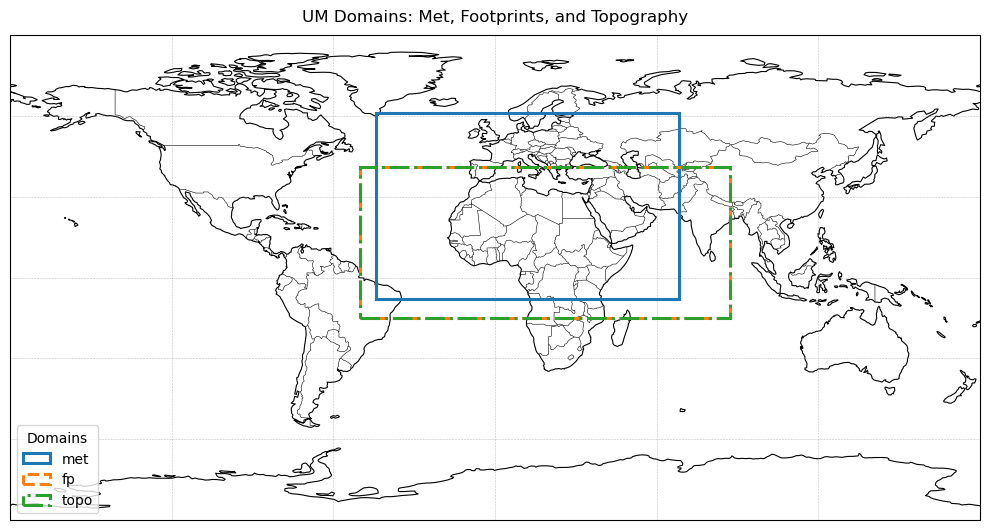

In [ ]:
data_x = LoadBaseSatelliteData(201603, region="SAHARA", load_everything=True, verbose=False)

# Plot all three series' with distinct styles

fig, ax = plot_multiple_data_series(
    data_x,
    show=("met", "fp", "topo"),
    colours={"met":"tab:blue", "fp":"tab:orange", "topo":"tab:green"},
    linestyles={"met":"-", "fp":"--", "topo":"-."},
    linewidths={"met":2.2, "fp":2.2, "topo":2.2},
    facealpha=0.0,                 # set to, e.g., 0.15 if you want light fills
    projection="PlateCarree",
    wrap_center=0,
    zoom_to_union=False,
    title="UM Domains: Met, Footprints, and Topography"
)
plt.show()

Cropping to intersection:
  lat: -7.980 → 40.926
  lon: -44.016 → 68.272


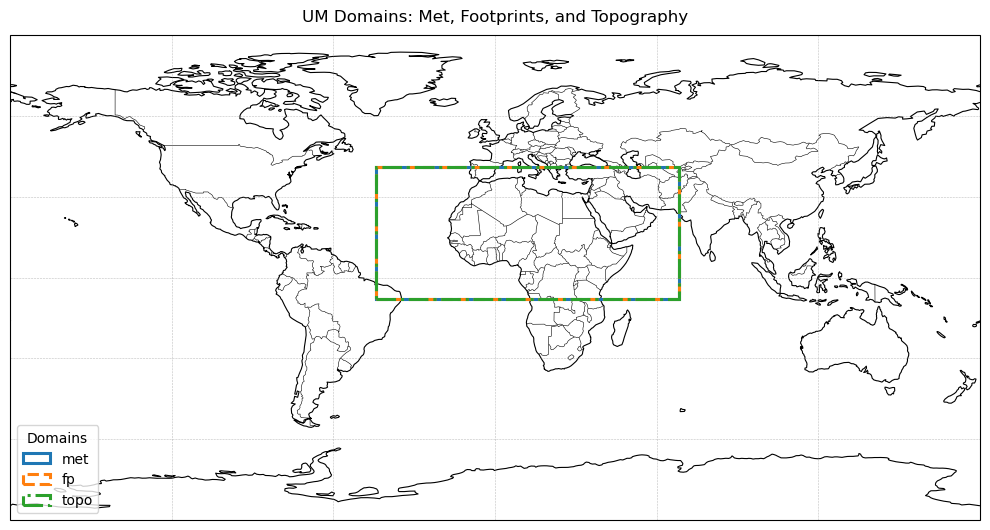

In [ ]:
data_x = LoadBaseSatelliteData(201603, region="SAHARA", load_everything=True, verbose=False)
data_x.align_domains()

# Plot all three series' with distinct styles

fig, ax = plot_multiple_data_series(
    data_x,
    show=("met", "fp", "topo"),
    colours={"met":"tab:blue", "fp":"tab:orange", "topo":"tab:green"},
    linestyles={"met":"-", "fp":"--", "topo":"-."},
    linewidths={"met":2.2, "fp":2.2, "topo":2.2},
    facealpha=0.0,                 # set to, e.g., 0.15 if you want light fills
    projection="PlateCarree",
    wrap_center=0,
    zoom_to_union=False,
    title="UM Domains: Met, Footprints, and Topography"
)
plt.show()